In [2]:
import pandas as pd
import numpy as np

# Load the Glass dataset
df = pd.read_excel("data/glass.xlsx", sheet_name="glass")

# Display first 5 rows
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
# Check dataset information
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Shape of dataset: (214, 10)

Column names:
Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='str')

Data types:
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Total missing values: 0


In [5]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [6]:
# Display duplicate rows, if any
df[df.duplicated()]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


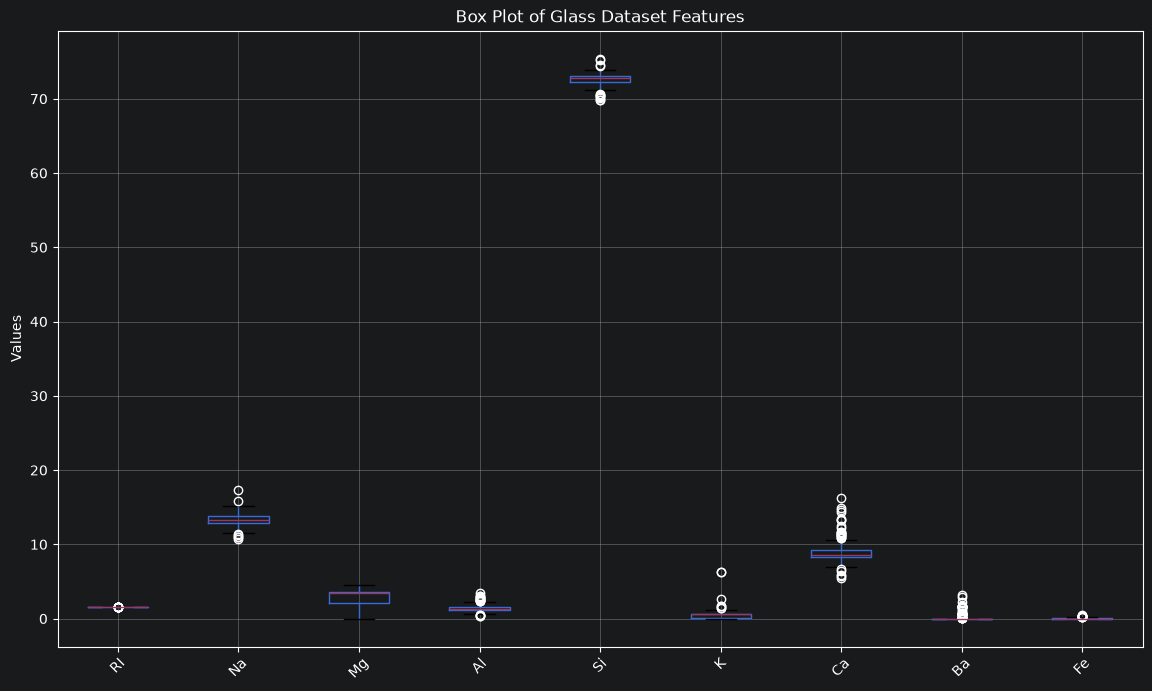

In [7]:
import matplotlib.pyplot as plt

# Feature columns (excluding target)
features = df.drop(columns=["Type"])

# Create box plots
plt.figure(figsize=(14, 8))
features.boxplot()
plt.title("Box Plot of Glass Dataset Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

In [8]:
# Check outliers using IQR method

Q1 = df[features.columns].quantile(0.25)
Q3 = df[features.columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((df[features.columns] < lower_bound) |
                  (df[features.columns] > upper_bound)).sum()

print("Outlier count for each feature:")
print(outlier_counts)

Outlier count for each feature:
RI    17
Na     7
Mg     0
Al    18
Si    12
K      7
Ca    26
Ba    38
Fe    12
dtype: int64


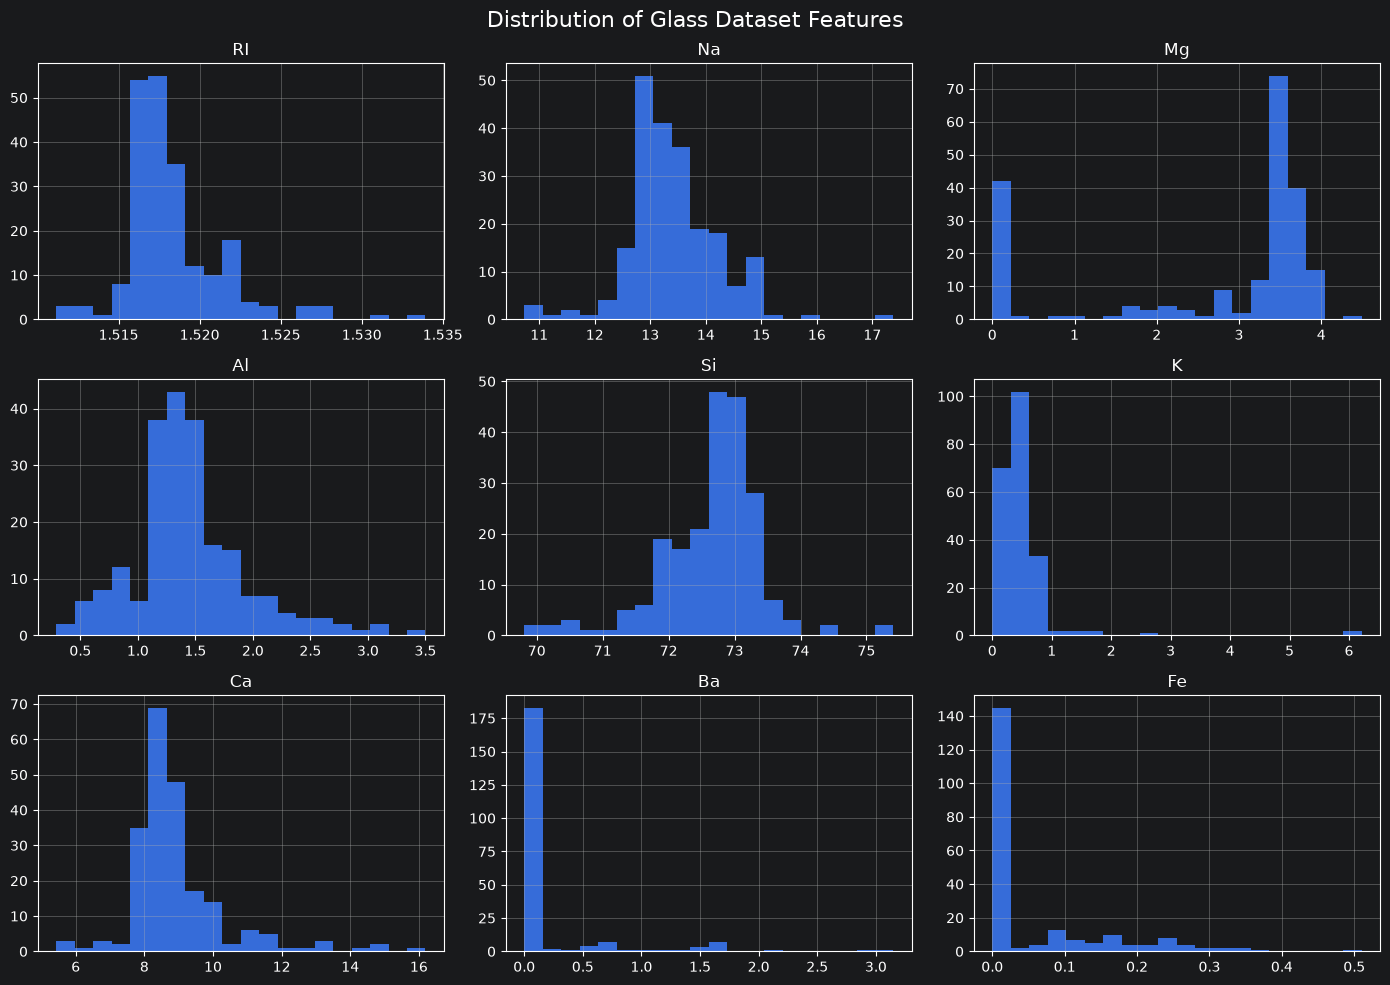

In [9]:
import matplotlib.pyplot as plt

# Plot histograms for all features
df[features.columns].hist(figsize=(14, 10), bins=20)

plt.suptitle("Distribution of Glass Dataset Features", fontsize=16)
plt.tight_layout()
plt.show()

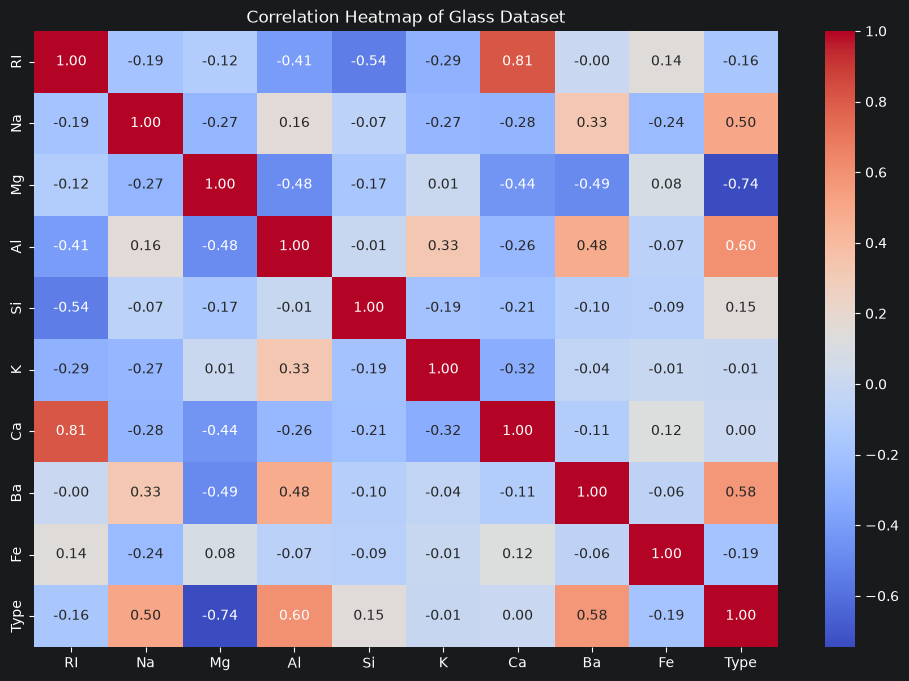

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Glass Dataset")
plt.show()

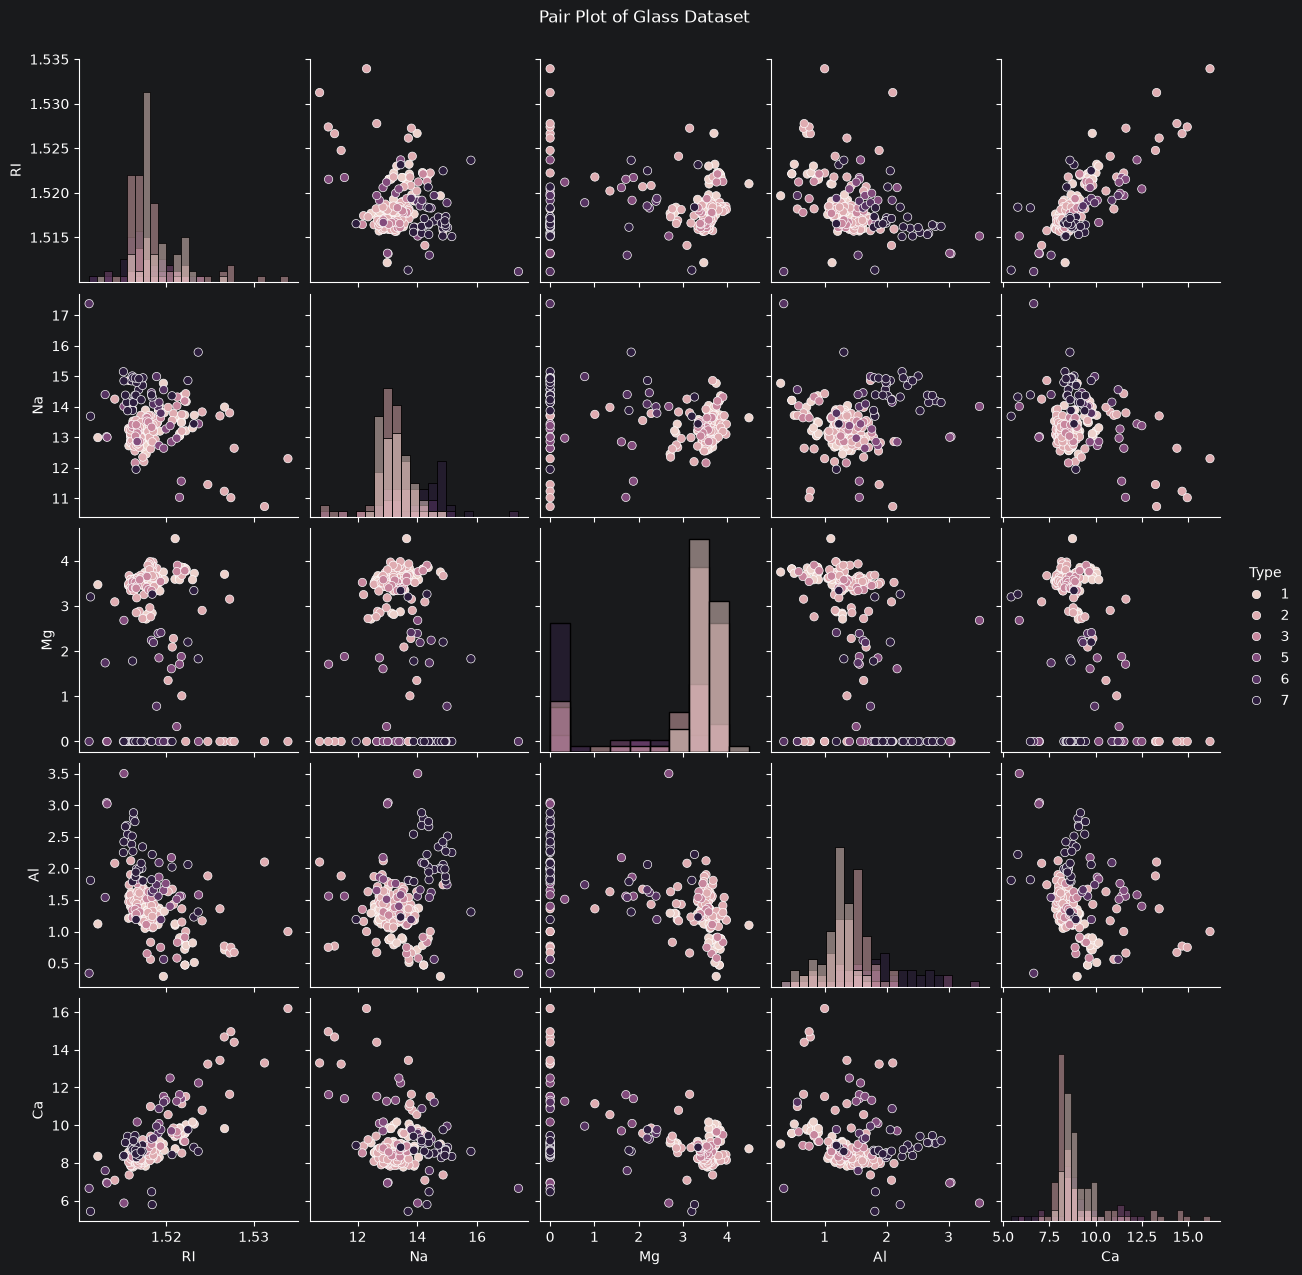

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important features along with target
pairplot_data = df[["RI", "Na", "Mg", "Al", "Ca", "Type"]]

# Create pair plot
sns.pairplot(
    pairplot_data,
    hue="Type",
    diag_kind="hist"
)

plt.suptitle("Pair Plot of Glass Dataset", y=1.02)
plt.show()

In [13]:
# Separate features and target variable

X = df.drop(columns=["Type"])
y = df["Type"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.value_counts().sort_index())

Features shape: (214, 9)
Target shape: (214,)

Feature columns:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

Target classes:
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training data shape: (171, 9)
Testing data shape: (43, 9)

Training class distribution:
Type
1    56
2    61
3    14
5    10
6     7
7    23
Name: count, dtype: int64

Testing class distribution:
Type
1    14
2    15
3     3
5     3
6     2
7     6
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (171, 9)
Scaled testing data shape: (43, 9)


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions on test data
y_pred = rf_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Random Forest Performance
-------------------------
Accuracy : 0.7441860465116279
Precision: 0.8071705426356588
Recall   : 0.7441860465116279
F1-Score : 0.7533118044745952

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.71      0.80        14
           2       0.82      0.60      0.69        15
           3       0.38      1.00      0.55         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       0.83      0.83      0.83         6

    accuracy                           0.74        43
   macro avg       0.73      0.86      0.75        43
weighted avg       0.81      0.74      0.75        43



Confusion Matrix:
[[10  1  3  0  0  0]
 [ 1  9  2  1  1  1]
 [ 0  0  3  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  5]]


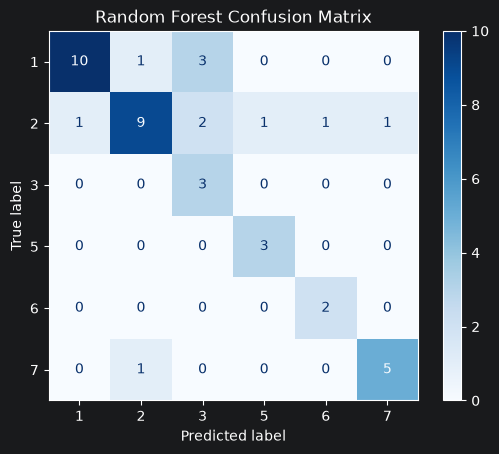

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [20]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Create Bagging classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

# Train the model
bagging_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_bagging = bagging_model.predict(X_test_scaled)

# Evaluate Bagging
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(
    y_test, y_pred_bagging, average="weighted", zero_division=0
)
bagging_recall = recall_score(
    y_test, y_pred_bagging, average="weighted", zero_division=0
)
bagging_f1 = f1_score(
    y_test, y_pred_bagging, average="weighted", zero_division=0
)

print("Bagging Performance")
print("-------------------")
print("Accuracy :", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall   :", bagging_recall)
print("F1-Score :", bagging_f1)

Bagging Performance
-------------------
Accuracy : 0.813953488372093
Precision: 0.8225232132208875
Recall   : 0.813953488372093
F1-Score : 0.811869365598315


In [21]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Create AdaBoost classifier
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Train the model
boosting_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_boosting = boosting_model.predict(X_test_scaled)

# Evaluate Boosting
boosting_accuracy = accuracy_score(y_test, y_pred_boosting)
boosting_precision = precision_score(
    y_test, y_pred_boosting, average="weighted", zero_division=0
)
boosting_recall = recall_score(
    y_test, y_pred_boosting, average="weighted", zero_division=0
)
boosting_f1 = f1_score(
    y_test, y_pred_boosting, average="weighted", zero_division=0
)

print("Boosting Performance")
print("--------------------")
print("Accuracy :", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall   :", boosting_recall)
print("F1-Score :", boosting_f1)

Boosting Performance
--------------------
Accuracy : 0.5116279069767442
Precision: 0.47629115070975536
Recall   : 0.5116279069767442
F1-Score : 0.4855456171735241


In [22]:
# Compare Random Forest, Bagging, and Boosting

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging",
        "Boosting (AdaBoost)"
    ],
    "Accuracy": [
        accuracy,
        bagging_accuracy,
        boosting_accuracy
    ],
    "Precision": [
        precision,
        bagging_precision,
        boosting_precision
    ],
    "Recall": [
        recall,
        bagging_recall,
        boosting_recall
    ],
    "F1-Score": [
        f1,
        bagging_f1,
        boosting_f1
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.744186   0.807171  0.744186  0.753312
1              Bagging  0.813953   0.822523  0.813953  0.811869
2  Boosting (AdaBoost)  0.511628   0.476291  0.511628  0.485546
